# VisionFM Fine-Tuning

**Model:** VisionFM (Vision Foundation Model) — ViT-Base backbone pretrained with self-supervised learning on fundus images  
**Task:** Binary glaucoma classification (Non-Glaucoma vs Glaucoma)  
**Dataset:** Color fundus photographs (CFP)  
**Fine-Tuning Strategies Compared:**
- **Partial Fine-Tuning:** Unfreeze last 2 transformer blocks + classification head with differential learning rates


---

## Table of Contents
- [Partial Fine-Tuning (Last 2 Blocks + Head)](#section-1)
   * 1.1 Environment Setup & Model Loading
   * 1.2 Dataset Preparation
   * 1.3 Fine-Tuning Configuration
   * 1.4 Training Loop
   * 1.5 Bootstrap Evaluation
   * 1.6 Attention Rollout Visualization



<a id='section-1'></a>
# Partial Fine-Tuning (Last 2 Blocks + Head)

> **Strategy:** Freeze the entire backbone. Unfreeze only the last 2 transformer blocks and the classification head.  
> Differential learning rates preserve pretrained representations in deeper layers.

---

## 1.1 Environment Setup & Model Loading


## Environment Sanity Check

In [1]:
# Confirm Python, NumPy, PyTorch, and CUDA versions are correct before running anything.
import sys, platform
print("Python:", sys.executable)
print("Arch:", platform.architecture())

import numpy as np
print("NumPy:", np.__version__)

import torch
print("Torch:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: C:\Users\Rama Alotaibi\anaconda3\envs\VisionFM\python.exe
Arch: ('64bit', 'WindowsPE')
NumPy: 1.21.6


C:\Users\Rama Alotaibi\anaconda3\envs\VisionFM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 1.11.0+cu113
Torch CUDA version: 11.3
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 SUPER


In [2]:
# Set all key paths in one place — VisionFM directory and pretrained weights.
# # - All downstream cells use these variables so changing them here is enough.

import os
from pathlib import Path

VISIONFM_DIR = r"D:\Rama\Glaucoma test\VisionFM\VisionFM"

WEIGHTS = r"D:\Rama\Glaucoma test\VisionFM\VisionFM\VFM_Fundus_weights.pth"

## Setting the dataset path (ROI-Combined)
The dataset follows a standard ImageFolder structure with three splits: training, val, and test, using a 60/20/20 split ratio (60% training, 20% validation, 20% test). 

In [3]:
DATA_ROOT = r"D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20"

In [4]:
# This cell Set output folder path in one place 
DATA_ROOT_FWD = DATA_ROOT.replace("\\\\", "/")   

EXP_NAME = "VisionFM_trying9"

OUTPUT_DIR = os.path.join(VISIONFM_DIR, "results", EXP_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

CKPT_SIMPLE = os.path.join(OUTPUT_DIR, f"{EXP_NAME}_best.pth")

CKPT_FULL   = os.path.join(OUTPUT_DIR, f"{EXP_NAME}_FULL.pth")

THRESHOLD_JSON = os.path.join(OUTPUT_DIR, f"{EXP_NAME}_thresholds.json")

os.chdir(VISIONFM_DIR)

print("CWD:", os.getcwd())
print("DATA_ROOT exists:", Path(DATA_ROOT).exists())
print("WEIGHTS exists:  ", Path(WEIGHTS).exists())
print("OUTPUT_DIR:      ", OUTPUT_DIR)

CWD: D:\Rama\Glaucoma test\VisionFM\VisionFM
DATA_ROOT exists: True
WEIGHTS exists:   True
OUTPUT_DIR:       D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9


## Reproducibility Seed

In [5]:
# Fix all random seeds so results are reproducible across runs.
# # - Covers Python, NumPy, PyTorch, and CUDA.
# # - seed_worker ensures DataLoader workers are also seeded.

import random
import numpy as np
import torch

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(42)
print("Seed set to 42")

Seed set to 42


## Load VisionFM Model

VisionFM uses a two-part architecture: a frozen ViT backbone that extracts features, and a lightweight classification head trained on top. We load the pretrained backbone weights and build the head separately.

In [6]:
# Load the VisionFM ViT-Base backbone and apply the pretrained fundus weights.
# # - Uses the teacher weights from the VisionFM self-supervised checkpoint.

import sys
EVALUATION_DIR = os.path.join(VISIONFM_DIR, 'evaluation')
sys.path.insert(0, EVALUATION_DIR)

import models
import utils
from models.head import ClsHead

backbone = models.__dict__['vit_base'](
    img_size=[224],
    patch_size=16,
    num_classes=0,
    use_mean_pooling=False
)

embed_dim = backbone.embed_dim

utils.load_pretrained_weights(backbone, WEIGHTS, 'teacher', 'vit_base', 16)

print(f"Backbone embed_dim: {embed_dim}")
print("VisionFM backbone loaded successfully")

Take key teacher in provided checkpoint dict
Pretrained weights found at D:\Rama\Glaucoma test\VisionFM\VisionFM\VFM_Fundus_weights.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v', 'head.last_layer2.weight_g', 'head.last_layer2.weight_v'])
Backbone embed_dim: 768
VisionFM backbone loaded successfully


In [7]:
# Build the classification head using features from the last 2 transformer blocks.
# # - N_LAST_BLOCKS=2: uses CLS token from last 2 blocks + mean patch pooling from last block.
# # - Total feature dim = embed_dim * N_LAST_BLOCKS (CLS tokens) + embed_dim (patch mean) = embed_dim * 3
# # - layers=2: smaller head reduces overfitting on small dataset.
# # - FIX: N_LAST_BLOCKS now matches FINETUNE_LAST_BLOCKS=2 for consistency.

N_LAST_BLOCKS = 2
NUM_LABELS    = 1   

# Feature dim = CLS tokens from 2 blocks + mean patch tokens from last block
HEAD_EMBED_DIM = embed_dim * N_LAST_BLOCKS + embed_dim  # 768*2 + 768 = 2304

cls_head = ClsHead(
    embed_dim=HEAD_EMBED_DIM,
    num_classes=NUM_LABELS,
    layers=2
)

print(utils.get_parameter_number(cls_head))
print(f"Classification head built (N_LAST_BLOCKS={N_LAST_BLOCKS}, HEAD_EMBED_DIM={HEAD_EMBED_DIM}, layers=2)")


{'Total': 1332865, 'Trainable': 1332865}
Classification head built (N_LAST_BLOCKS=2, HEAD_EMBED_DIM=2304, layers=2)


In [8]:
# Move backbone and classification head to GPU if available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone  = backbone.to(device)
cls_head  = cls_head.to(device)
print(f"Model running on: {device}")

Model running on: cuda


In [9]:
# Add Dropout(0.1) before the classification head.

import torch.nn as nn

cls_head = nn.Sequential(
    nn.Dropout(p=0.1),
    cls_head
)
cls_head = cls_head.to(device)
print("Dropout(p=0.1) added to head ✓")


Dropout(p=0.1) added to head ✓


## Freeze Backbone — Unfreeze Last 2 Blocks + Head

In [10]:
# Freeze all backbone parameters first, then unfreeze the last 2 transformer blocks.
# # - Last 2 blocks + classification head will be trained.
# # - Differential LRs: block[-1] gets 3e-7, block[-2] gets 1e-7, head gets 1e-5.

for param in backbone.parameters():
    param.requires_grad = False

FINETUNE_LAST_BLOCKS = 2

for param in backbone.blocks[-1].parameters():
    param.requires_grad = True
for param in backbone.blocks[-2].parameters():
    param.requires_grad = True

if hasattr(backbone, 'norm'):
    for param in backbone.norm.parameters():
        param.requires_grad = True

backbone_total     = sum(p.numel() for p in backbone.parameters())
backbone_trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
backbone_frozen    = backbone_total - backbone_trainable

print(f"Backbone — Total params        : {backbone_total:,}")
print(f"Backbone — Trainable (2 blocks): {backbone_trainable:,}")
print(f"Backbone — Frozen              : {backbone_frozen:,}")
print(f"Head     — Trainable           : {sum(p.numel() for p in cls_head.parameters()):,}")
print("Last 2 backbone blocks + head unfrozen ✓")


Backbone — Total params        : 85,798,656
Backbone — Trainable (2 blocks): 14,177,280
Backbone — Frozen              : 71,621,376
Head     — Trainable           : 1,332,865
Last 2 backbone blocks + head unfrozen ✓


## 1.2 Dataset Preparation

In [11]:
# Read each split label file and count total images, glaucoma, and non-glaucoma samples.
# # - Helps spot class imbalance and confirm the dataset is correctly structured.

for split in ['training', 'val', 'test']:
    label_file = Path(DATA_ROOT) / f"{split}_labels.txt"
    print(f"\n{split.upper()} — label file exists: {label_file.exists()}")
    
    if label_file.exists():
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        total = len(lines)
        pos = sum(1 for l in lines if l.strip().split(";")[-1] == '1')
        neg = sum(1 for l in lines if l.strip().split(";")[-1] == '0')
        
        print(f"  Total images : {total}")
        print(f"  Glaucoma (1) : {pos}")
        print(f"  Non-Glaucoma (0): {neg}")


TRAINING — label file exists: True
  Total images : 1559
  Glaucoma (1) : 731
  Non-Glaucoma (0): 828

VAL — label file exists: True
  Total images : 519
  Glaucoma (1) : 243
  Non-Glaucoma (0): 276

TEST — label file exists: True
  Total images : 522
  Glaucoma (1) : 245
  Non-Glaucoma (0): 277


## Augmentation & Transforms

In [12]:
# Define training and evaluation transforms using VisionFM custom transform classes.
# # - Training: crop, affine, color jitter, gamma, flips, and normalization.
# # - Evaluation: resize and normalize only.
# # - RandomGamma mimics real-world fundus image brightness variation.

import torchvision.transforms.functional as tvF
from torchvision.transforms import InterpolationMode
import transforms as self_transforms   

class RandomGamma:
    def __init__(self, gamma_range=(0.7, 1.5), p=0.3):
        self.gmin, self.gmax = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            gamma = random.uniform(self.gmin, self.gmax)
            img = tvF.adjust_gamma(img, gamma=gamma, gain=1.0)
        return img

mean, std = utils.get_stats('Fundus')
print(f"Fundus mean: {mean}")
print(f"Fundus std : {std}")

train_transform = self_transforms.Compose([
    self_transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.75, 1.0),        
        interpolation=InterpolationMode.BICUBIC
    ),
    self_transforms.RandomAffine(
        degrees=15,                  
        translate=(0.05, 0.05),     
        scale=(0.90, 1.10),          
        shear=None,
        interpolation=InterpolationMode.BICUBIC
    ),
    self_transforms.ColorJitter(
        brightness=0.20,             
        contrast=0.20,             
        saturation=0.10,          
        hue=0.02
    ),
    RandomGamma(gamma_range=(0.7, 1.5), p=0.4),   
    self_transforms.RandomHorizontalFlip(),
    self_transforms.RandomVerticalFlip(),          
    self_transforms.ToTensor(),
    self_transforms.Normalize(mean, std),
])

val_transform = self_transforms.Compose([
    self_transforms.Resize(size=(224, 224), interpolation=InterpolationMode.BICUBIC),
    self_transforms.ToTensor(),
    self_transforms.Normalize(mean, std),
])

print("Transforms ready")

Fundus mean: (0.423737496137619, 0.2609460651874542, 0.128403902053833)
Fundus std : (0.29482534527778625, 0.20167365670204163, 0.13668020069599152)
Transforms ready


## Load Dataset

In [13]:
# Convert label files from space-separated to semicolon-separated format.
# # - Required by the ClsImgs dataset class which expects this delimiter.

import os

for split in ['training', 'val', 'test']:
    label_file = os.path.join(DATA_ROOT, f'{split}_labels.txt')

    with open(label_file, 'r') as f:
        lines = f.readlines()

    # Guard: skip conversion if already semicolon-formatted
    if lines and ';' in lines[0]:
        print(f" {split}_labels.txt already converted — skipping")
        continue

    new_lines = [line.strip().replace(' ', ';', 1) + '\n' for line in lines if line.strip()]

    with open(label_file, 'w') as f:
        f.writelines(new_lines)

    print(f" {split}_labels.txt converted — {len(new_lines)} lines")

 training_labels.txt already converted — skipping
 val_labels.txt already converted — skipping
 test_labels.txt already converted — skipping


In [14]:
# Load train, val, and test datasets using the VisionFM ClsImgs class.
# # - Reads images and labels from the text files converted above.

from dataset import ClsImgs

dataset_train = ClsImgs(root=DATA_ROOT, split='training', transform=train_transform)
dataset_val   = ClsImgs(root=DATA_ROOT, split='val',      transform=val_transform)
dataset_test  = ClsImgs(root=DATA_ROOT, split='test',     transform=val_transform)

print(f"Train: {len(dataset_train)} images")
print(f"Val  : {len(dataset_val)}   images")
print(f"Test : {len(dataset_test)}  images")

reading images at D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20 (single-dataset root detected)
there are 1559 imgs in the D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20\training_labels.txt
there are 1559 images in the training set.
reading images at D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20 (single-dataset root detected)
there are 519 imgs in the D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20\val_labels.txt
there are 519 images in the val set.
reading images at D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20 (single-dataset root detected)
there are 522 imgs in the D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20\test_labels.txt
there are 522 images in the test set.
Train: 1559 images
Val  : 519   images
Test : 522  images


In [15]:
# Create DataLoaders with WeightedRandomSampler for the training set.
# # - Sampler oversamples the minority class (glaucoma) to handle class imbalance.
# # - Val and test loaders use no shuffling for consistent evaluation.
# # - FIX: drop_last=False — every sample counts in a small medical dataset.

g = torch.Generator()
g.manual_seed(42)

labels_train = []
for i in range(len(dataset_train)):
    _, y, _ = dataset_train[i]
    labels_train.append(int(y.item()) if hasattr(y, "item") else int(y))

labels_train = np.array(labels_train)
class_counts = np.bincount(labels_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[labels_train]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(labels_train),
    replacement=True,
    generator=g
)

train_loader = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=32,
    sampler=sampler,               
    num_workers=0,
    pin_memory=True,
    drop_last=False  # every sample matters in small medical datasets
)

val_loader = torch.utils.data.DataLoader(
    dataset_val,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Class counts — Non-Glaucoma: {class_counts[0]}, Glaucoma: {class_counts[1]}")
print("DataLoaders ready (WeightedRandomSampler active, drop_last=False)")


Class counts — Non-Glaucoma: 828, Glaucoma: 731
DataLoaders ready (WeightedRandomSampler active, drop_last=False)


## Sanity Check — Forward Pass Before Training

In [16]:
# Run one forward pass through backbone and head before training.
# # - Confirms the two-part pipeline works end-to-end.
# # - NaN/Inf checks catch any initialization issues early.
# # - Uses same feature extraction as training: CLS tokens + mean patch tokens.

backbone.eval()
cls_head.eval()

sample_batch, sample_labels, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    intermediate = backbone.get_intermediate_layers(sample_batch, N_LAST_BLOCKS)
    cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)     # [B, 768*2]
    patch_feats = intermediate[-1][:, 1:].mean(dim=1)                     # [B, 768]
    feats = torch.cat([cls_feats, patch_feats], dim=-1)                   # [B, 2304]
    out   = cls_head(feats)

print("Input shape :", sample_batch.shape)
print("Feature shape:", feats.shape)
print("Output shape :", out.shape)
print("NaN check    :", torch.isnan(out).any().item())
print("Inf check    :", torch.isinf(out).any().item())
print("Sanity check passed ")


Input shape : torch.Size([32, 3, 224, 224])
Feature shape: torch.Size([32, 2304])
Output shape : torch.Size([32, 1])
NaN check    : False
Inf check    : False
Sanity check passed 


## 1.3 Fine-Tuning Configuration

## Loss Function — Plain BCEWithLogitsLoss

In [17]:
# Define plain BCE loss — no pos_weight, no label smoothing.
# # - WeightedRandomSampler already balances classes during training.
# # - Plain BCEWithLogitsLoss gives cleaner gradients on balanced batches.

import torch.nn as nn

pos = int((labels_train == 1).sum())
neg = int((labels_train == 0).sum())

print(f"Positives (glaucoma)    : {pos}")
print(f"Negatives (non-glaucoma): {neg}")
print(f"Class balance handled by WeightedRandomSampler — no pos_weight needed.")

criterion = nn.BCEWithLogitsLoss()
print("Loss: BCEWithLogitsLoss (plain) — imbalance handled by WeightedRandomSampler ✓")


Positives (glaucoma)    : 731
Negatives (non-glaucoma): 828
Class balance handled by WeightedRandomSampler — no pos_weight needed.
Loss: BCEWithLogitsLoss (plain) — imbalance handled by WeightedRandomSampler ✓


## Optimizer & LR Scheduler

In [18]:
# Differential learning rates across param groups:
# # - block[-1] (last block)      : 3e-7  — fine-tune closest to output
# # - block[-2] (second-to-last)  : 1e-7  — more conservative for deeper block
# # - classification head          : 1e-5  — head needs most updating

EPOCHS        = 50
LR_HEAD       = 1e-5
LR_BLOCK_LAST = 3e-7
LR_BLOCK_PREV = 1e-7   
WARMUP_EPOCHS = 3

block_last_params = [p for p in backbone.blocks[-1].parameters() if p.requires_grad]
block_prev_params = [p for p in backbone.blocks[-2].parameters() if p.requires_grad]
norm_params       = [p for p in backbone.norm.parameters() if p.requires_grad] if hasattr(backbone, "norm") else []
head_params       = list(cls_head.parameters())

optimizer = torch.optim.AdamW(
    [
        {"params": block_last_params, "lr": LR_BLOCK_LAST, "weight_decay": 0.01},
        {"params": block_prev_params, "lr": LR_BLOCK_PREV, "weight_decay": 0.01},
        {"params": norm_params,       "lr": LR_BLOCK_LAST, "weight_decay": 0.01},
        {"params": head_params,       "lr": LR_HEAD,       "weight_decay": 0.01},
    ],
    betas=(0.9, 0.999)
)

# Using only ReduceLROnPlateau which adapts to actual val loss behavior.
plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, verbose=True
)
scaler = torch.cuda.amp.GradScaler(enabled=True)

print(f"Optimizer  : AdamW with differential LRs")
print(f"  Head LR         : {LR_HEAD}")
print(f"  Block[-1] LR    : {LR_BLOCK_LAST}")
print(f"  Block[-2] LR    : {LR_BLOCK_PREV}  ← FIXED (was 1e-5)")
print(f"Scheduler  : ReduceLROnPlateau only (cosine removed — was conflicting)")
print(f"Backbone   : Last 2 blocks unfrozen")
print(f"AMP        : Enabled | Grad clip: 1.0")


Optimizer  : AdamW with differential LRs
  Head LR         : 1e-05
  Block[-1] LR    : 3e-07
  Block[-2] LR    : 1e-07  ← FIXED (was 1e-5)
Scheduler  : ReduceLROnPlateau only (cosine removed — was conflicting)
Backbone   : Last 2 blocks unfrozen
AMP        : Enabled | Grad clip: 1.0


In [19]:
# PARAMETER COUNT 
backbone_total     = sum(p.numel() for p in backbone.parameters())
backbone_trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
backbone_frozen    = backbone_total - backbone_trainable

head_total         = sum(p.numel() for p in cls_head.parameters())
head_trainable     = sum(p.numel() for p in cls_head.parameters() if p.requires_grad)

total_trainable    = backbone_trainable + head_trainable
total_all          = backbone_total + head_total

print("=" * 50)
print("MODEL PARAMETER COUNT")
print("=" * 50)
print(f"Backbone — Total    : {backbone_total:,}")
print(f"Backbone — Trainable: {backbone_trainable:,}")
print(f"Backbone — Frozen   : {backbone_frozen:,}")
print(f"Head     — Total    : {head_total:,}")
print(f"Head     — Trainable: {head_trainable:,}")
print("-" * 50)
print(f"Total (all)         : {total_all:,}")
print(f"Total (trainable)   : {total_trainable:,}")
print("=" * 50)

MODEL PARAMETER COUNT
Backbone — Total    : 85,798,656
Backbone — Trainable: 14,177,280
Backbone — Frozen   : 71,621,376
Head     — Total    : 1,332,865
Head     — Trainable: 1,332,865
--------------------------------------------------
Total (all)         : 87,131,521
Total (trainable)   : 15,510,145


## 1.4 Training Loop

In [20]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

best_auc         = 0.0
train_losses     = []
val_losses       = []

patience         = 5
patience_counter = 0

for epoch in range(EPOCHS):

    backbone.eval()
    backbone.blocks[-1].train()
    backbone.blocks[-2].train()
    if hasattr(backbone, "norm"):
        backbone.norm.train()
    cls_head.train()

    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for inp, target, extras in train_loader:
        inp    = inp.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True).long().squeeze()

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=True):
            intermediate = backbone.get_intermediate_layers(inp, N_LAST_BLOCKS)
            cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)  # [B, 768*2]
            patch_feats = intermediate[-1][:, 1:].mean(dim=1)                  # [B, 768]
            feats = torch.cat([cls_feats, patch_feats], dim=-1)                # [B, 2304]
            out   = cls_head(feats)
            loss  = criterion(out.squeeze(1), target.float())

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(cls_head.parameters()) +
            list(backbone.blocks[-1].parameters()) +
            list(backbone.blocks[-2].parameters()),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        preds = (out.squeeze(1).sigmoid() > 0.5).long()
        train_correct += (preds == target).sum().item()
        train_total   += target.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = train_correct / train_total
    train_losses.append(avg_train_loss)

    backbone.eval()
    cls_head.eval()

    val_loss   = 0.0
    y_val_true = []
    y_val_prob = []

    with torch.no_grad():
        for inp, target, extras in val_loader:
            inp    = inp.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True).long().squeeze()

            intermediate = backbone.get_intermediate_layers(inp, N_LAST_BLOCKS)
            cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)  # [B, 768*2]
            patch_feats = intermediate[-1][:, 1:].mean(dim=1)                  # [B, 768]
            feats = torch.cat([cls_feats, patch_feats], dim=-1)                # [B, 2304]
            out   = cls_head(feats)
            loss  = criterion(out.squeeze(1), target.float())

            val_loss += loss.item()
            probs = out.squeeze(1).sigmoid()
            y_val_true.extend(target.cpu().numpy())
            y_val_prob.extend(probs.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    y_val_true = np.array(y_val_true)
    y_val_prob = np.array(y_val_prob)
    y_val_pred = (y_val_prob > 0.5).astype(int)

    if np.isnan(y_val_prob).any():
        print(f"   NaN detected in predictions at epoch {epoch+1} — skipping metrics")
        val_auc       = float("nan")
        val_f1        = 0.0
        val_precision = 0.0
        val_recall    = 0.0
    else:
        val_auc = roc_auc_score(y_val_true, y_val_prob) if len(np.unique(y_val_true)) > 1 else float("nan")
        pcf     = precision_recall_fscore_support(y_val_true, y_val_pred, average="macro", zero_division=0)
        val_precision, val_recall, val_f1 = pcf[0], pcf[1], pcf[2]

    # FIX: Only plateau scheduler
    plateau_scheduler.step(avg_val_loss)

    current_lr_head = optimizer.param_groups[3]["lr"]
    print(f"Epoch {epoch+1}/{EPOCHS}  [LR head={current_lr_head:.2e}]")
    print(f"  Train — Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Val   — Loss: {avg_val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")

    # FIX: >= changed to > so equal AUC does not falsely reset patience counter
    if not np.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0

        torch.save(backbone.state_dict(), CKPT_SIMPLE)
        print(f"   Best AUC={best_auc:.4f} — simple checkpoint saved → {CKPT_SIMPLE}")

        torch.save({
            "backbone_state_dict":  backbone.state_dict(),
            "head_state_dict":      cls_head.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch":      epoch,
            "best_auc":   float(best_auc),
            "exp_name":   EXP_NAME,
            "normalization": {
                "mean": mean,
                "std":  std
            },
            "input_size":           224,
            "num_labels":           NUM_LABELS,
            "n_last_blocks":        N_LAST_BLOCKS,
            "finetune_last_blocks": FINETUNE_LAST_BLOCKS,
        }, CKPT_FULL)
        print(f"   Full checkpoint saved  → {CKPT_FULL}")

    else:
        patience_counter += 1
        print(f"   No improvement. Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\n Early stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete. Best Val AUC: {best_auc:.4f}")


Epoch 1/50  [LR head=1.00e-05]
  Train — Loss: 0.6694 | Acc: 0.6536
  Val   — Loss: 0.6287 | AUC: 0.8448 | F1: 0.7717 | Precision: 0.7717 | Recall: 0.7717
   Best AUC=0.8448 — simple checkpoint saved → D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9\VisionFM_trying9_best.pth
   Full checkpoint saved  → D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9\VisionFM_trying9_FULL.pth
Epoch 2/50  [LR head=1.00e-05]
  Train — Loss: 0.6419 | Acc: 0.7107
  Val   — Loss: 0.5920 | AUC: 0.8585 | F1: 0.7712 | Precision: 0.7721 | Recall: 0.7707
   Best AUC=0.8585 — simple checkpoint saved → D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9\VisionFM_trying9_best.pth
   Full checkpoint saved  → D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9\VisionFM_trying9_FULL.pth
Epoch 3/50  [LR head=1.00e-05]
  Train — Loss: 0.6071 | Acc: 0.7344
  Val   — Loss: 0.5544 | AUC: 0.8606 | F1: 0.7766 | Precision: 0.7850 | Recall: 0.7753
   Best AUC=0.8606 — 

## Loss Curve Plot

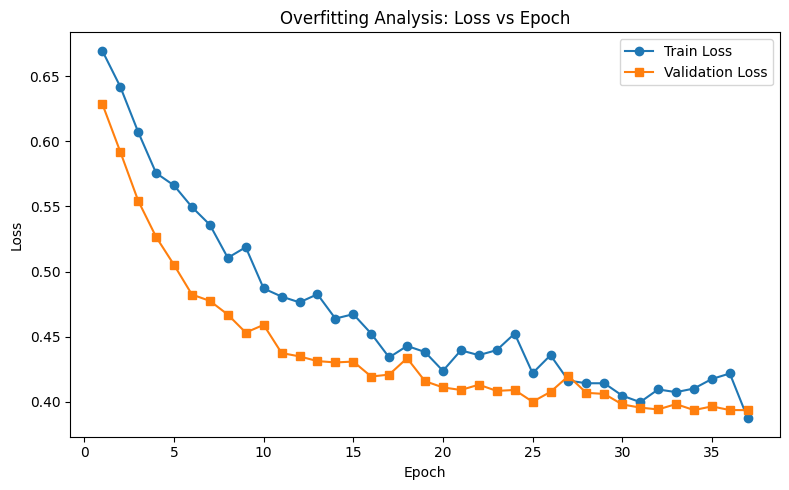

Loss curve saved to D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9


In [21]:
# Plot training vs validation loss across epochs and save the figure.

import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Analysis: Loss vs Epoch')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'), dpi=150)
plt.show()
print(f"Loss curve saved to {OUTPUT_DIR}")

## 1.5 Bootstrap Evaluation

## Load Best Checkpoint for Evaluation

In [22]:
# Load the best saved checkpoint for final evaluation.
# # - Restores both backbone and head weights from the best-AUC epoch.

checkpoint = torch.load(CKPT_FULL, map_location=device)
backbone.load_state_dict(checkpoint['backbone_state_dict'])
cls_head.load_state_dict(checkpoint['head_state_dict'])
backbone  = backbone.to(device)
cls_head  = cls_head.to(device)
backbone.eval()
cls_head.eval()
print(f"Best checkpoint loaded (epoch {checkpoint['epoch']+1}, AUC={checkpoint['best_auc']:.4f}) ")

Best checkpoint loaded (epoch 32, AUC=0.8918) 


## Collect Probabilities

In [23]:
# Run the model on a dataloader and collect true labels and predicted probabilities.
# # - collect_probs: standard single-pass inference.
# # - collect_probs_tta: Test-Time Augmentation — runs N_TTA forward passes with
# #   random flips and averages the probabilities. Free AUC boost, no retraining.
# # - Both functions now use CLS tokens + mean patch tokens (matches training).

import torchvision.transforms as T

N_TTA = 5  # number of TTA augmentation passes

def collect_probs(loader):
    y_true, y_prob = [], []
    backbone.eval()
    cls_head.eval()
    with torch.no_grad():
        for inp, target, extras in loader:
            inp    = inp.to(device)
            target = target.long().squeeze()
            intermediate = backbone.get_intermediate_layers(inp, N_LAST_BLOCKS)
            cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)
            patch_feats = intermediate[-1][:, 1:].mean(dim=1)
            feats = torch.cat([cls_feats, patch_feats], dim=-1)
            out   = cls_head(feats)
            probs = out.squeeze(1).sigmoid()
            y_true.extend(target.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_prob)


def collect_probs_tta(loader, n_tta=N_TTA):
    """
    For each image, runs n_tta forward passes with random H/V flips
    and averages the sigmoid probabilities.
    """
    tta_flip_h = T.RandomHorizontalFlip(p=0.5)
    tta_flip_v = T.RandomVerticalFlip(p=0.5)

    backbone.eval()
    cls_head.eval()

    y_true_all = []
    y_prob_all = []

    with torch.no_grad():
        for inp, target, extras in loader:
            inp    = inp.to(device)
            target = target.long().squeeze()

            batch_probs = torch.zeros(inp.shape[0], device=device)
            for _ in range(n_tta):
                inp_aug = tta_flip_h(inp)
                inp_aug = tta_flip_v(inp_aug)
                intermediate = backbone.get_intermediate_layers(inp_aug, N_LAST_BLOCKS)
                cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)
                patch_feats = intermediate[-1][:, 1:].mean(dim=1)
                feats = torch.cat([cls_feats, patch_feats], dim=-1)
                out   = cls_head(feats)
                batch_probs += out.squeeze(1).sigmoid()

            batch_probs /= n_tta

            y_true_all.extend(target.cpu().numpy())
            y_prob_all.extend(batch_probs.cpu().numpy())

    return np.array(y_true_all), np.array(y_prob_all)


print(f"collect_probs     : standard single-pass inference ready")
print(f"collect_probs_tta : TTA inference ready (n_tta={N_TTA}, H+V flips)")


collect_probs     : standard single-pass inference ready
collect_probs_tta : TTA inference ready (n_tta=5, H+V flips)


## Threshold Selection on Validation Set

Validation set size: 519 images
Running TTA inference on validation set (n_tta=5)...


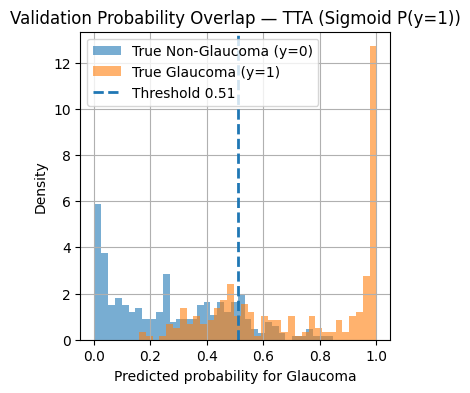

Youden threshold (from val TTA): 0.4556
FIXED_THRESHOLD set to Youden  : 0.5100


In [24]:
# Compute the Youden-optimal threshold from the validation set using TTA inference.
# # - TTA averages 5 augmented views per image for more stable probability estimates.

from sklearn.metrics import roc_curve

def youden_threshold(y_true_val, y_prob_val):
    fpr, tpr, thresholds = roc_curve(y_true_val, y_prob_val)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

def plot_overlap_hist(y_true, y_prob, bins=35, thr_line=None):
    neg = y_prob[y_true == 0]
    pos = y_prob[y_true == 1]
    plt.figure(figsize=(4, 4))
    plt.hist(neg, bins=bins, alpha=0.6, density=True, label="True Non-Glaucoma (y=0)")
    plt.hist(pos, bins=bins, alpha=0.6, density=True, label="True Glaucoma (y=1)")
    if thr_line is not None:
        plt.axvline(thr_line, linestyle="--", linewidth=2, label=f"Threshold {thr_line:.2f}")
    plt.title("Validation Probability Overlap — TTA (Sigmoid P(y=1))")
    plt.xlabel("Predicted probability for Glaucoma")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

print(f"Validation set size: {len(dataset_val)} images")
print(f"Running TTA inference on validation set (n_tta={N_TTA})...")
y_val_true, y_val_prob = collect_probs_tta(val_loader)

best_threshold_youden = youden_threshold(y_val_true, y_val_prob)
FIXED_THRESHOLD = 0.51  

plot_overlap_hist(y_val_true, y_val_prob, bins=35, thr_line=FIXED_THRESHOLD)

print(f"Youden threshold (from val TTA): {best_threshold_youden:.4f}")
print(f"FIXED_THRESHOLD set to Youden  : {FIXED_THRESHOLD:.4f}")


## Save Thresholds JSON

In [25]:
# Save threshold values and model metadata to a JSON file.
# # - Used later for inference or model fusion without re-running the notebook.

import json

thresholds_info = {
    "fixed_threshold":  float(FIXED_THRESHOLD),
    "youden_threshold": float(best_threshold_youden),
    "pos_class":        "glaucoma",
    "pos_label":        1,
    "model":            "VisionFM_vit_base",
    "exp_name":         EXP_NAME,
}

with open(THRESHOLD_JSON, 'w') as f:
    json.dump(thresholds_info, f, indent=4)

print(f" Threshold config saved → {THRESHOLD_JSON}")
print(json.dumps(thresholds_info, indent=4))

 Threshold config saved → D:\Rama\Glaucoma test\VisionFM\VisionFM\results\VisionFM_trying9\VisionFM_trying9_thresholds.json
{
    "fixed_threshold": 0.51,
    "youden_threshold": 0.45556575059890747,
    "pos_class": "glaucoma",
    "pos_label": 1,
    "model": "VisionFM_vit_base",
    "exp_name": "VisionFM_trying9"
}


## Test Set Evaluation with Bootstrap CI

Bootstrap resampling gives confidence intervals around each metric. This is more reliable than a single point estimate, it shows how stable the results are and provides a 95% CI for reporting.

In [26]:
# Define metric computation and bootstrap CI functions.
# # - metrics_at_threshold: builds confusion matrix and derives all metrics.
# # - bootstrap_ci: resamples stratified positives/negatives 1000 times to compute 95% CI.
# # - print_results: prints a formatted table with values, CI, and confusion matrix.

from sklearn.metrics import (
    confusion_matrix, precision_score, f1_score, roc_auc_score
)

N_BOOTSTRAP  = 1000
CI_ALPHA     = 0.95
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = precision_score(y_true, y_pred, zero_division=0)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    auc         = roc_auc_score(y_true, y_prob)
    return dict(TN=TN, FP=FP, FN=FN, TP=TP,
                accuracy=accuracy, sensitivity=sensitivity,
                specificity=specificity, precision=precision,
                f1=f1, auc=auc)

def bootstrap_ci(y_true, y_prob, threshold, n=N_BOOTSTRAP):
    metric_keys = ['auc', 'accuracy', 'sensitivity', 'specificity', 'precision', 'f1']
    records = {k: [] for k in metric_keys}
    idx_neg = np.where(y_true == 0)[0]
    idx_pos = np.where(y_true == 1)[0]
    rng_b   = np.random.default_rng(RANDOM_STATE)
    for _ in range(n):
        boot_neg = rng_b.choice(idx_neg, size=len(idx_neg), replace=True)
        boot_pos = rng_b.choice(idx_pos, size=len(idx_pos), replace=True)
        idx = np.concatenate([boot_neg, boot_pos])
        m = metrics_at_threshold(y_true[idx], y_prob[idx], threshold)
        for k in metric_keys:
            records[k].append(m[k])
    lo = (1 - CI_ALPHA) / 2 * 100
    hi = (1 + CI_ALPHA) / 2 * 100
    return {k: (np.percentile(records[k], lo), np.percentile(records[k], hi)) for k in metric_keys}

def print_results(label, m, ci, thr):
    bar = '=' * 62
    print(f'\n{bar}')
    print(f'FINAL TEST RESULTS — {label}')
    print(f'Threshold : {thr:.4f}    (Bootstrap n={N_BOOTSTRAP}, CI={int(CI_ALPHA*100)}%)')
    print(bar)
    print(f"{'Metric':<14}  {'Value':>7}   {'95% CI':>20}")
    print('-' * 46)
    for name, key in [('AUC','auc'),('Accuracy','accuracy'),('Sensitivity','sensitivity'),
                      ('Specificity','specificity'),('Precision','precision'),('F1-score','f1')]:
        lo, hi_ = ci[key]
        print(f"{name:<14}  {m[key]:>7.4f}   [{lo:.4f} – {hi_:.4f}]")
    print(bar)
    print('\nConfusion Matrix:')
    print(f"              Predicted")
    print(f"              Non-Glau  Glaucoma")
    print(f"True Non-Glau    {m['TN']:4d}      {m['FP']:4d}")
    print(f"True Glaucoma    {m['FN']:4d}      {m['TP']:4d}")
    print(bar)

In [27]:
# Run TTA inference on the test set and collect predictions for final reporting.
print(f"Test set size: {len(dataset_test)} images")
print(f"Running TTA inference on test set (n_tta={N_TTA})...")
y_true, y_prob = collect_probs_tta(test_loader)
print("TTA inference complete.")


Test set size: 522 images
Running TTA inference on test set (n_tta=5)...
TTA inference complete.


In [28]:
# Evaluate and report results using the Youden-derived threshold.
thr_A = FIXED_THRESHOLD
m_A   = metrics_at_threshold(y_true, y_prob, thr_A)
ci_A  = bootstrap_ci(y_true, y_prob, thr_A)
print_results(f"Fixed Threshold = {thr_A:.4f}", m_A, ci_A, thr_A)



FINAL TEST RESULTS — Fixed Threshold = 0.5100
Threshold : 0.5100    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9278   [0.9063 – 0.9462]
Accuracy         0.8142   [0.7796 – 0.8448]
Sensitivity      0.8041   [0.7551 – 0.8531]
Specificity      0.8231   [0.7798 – 0.8664]
Precision        0.8008   [0.7614 – 0.8414]
F1-score         0.8024   [0.7639 – 0.8354]

Confusion Matrix:
              Predicted
              Non-Glau  Glaucoma
True Non-Glau     228        49
True Glaucoma      48       197


In [29]:
# Evaluate and report results using the Youden-optimal threshold from validation.
thr_B = best_threshold_youden
m_B   = metrics_at_threshold(y_true, y_prob, thr_B)
ci_B  = bootstrap_ci(y_true, y_prob, thr_B)
print_results('Youden Threshold (from Val)', m_B, ci_B, thr_B)


FINAL TEST RESULTS — Youden Threshold (from Val)
Threshold : 0.4556    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9278   [0.9063 – 0.9462]
Accuracy         0.8257   [0.7931 – 0.8563]
Sensitivity      0.9061   [0.8735 – 0.9429]
Specificity      0.7545   [0.7004 – 0.8051]
Precision        0.7655   [0.7282 – 0.8036]
F1-score         0.8299   [0.8000 – 0.8582]

Confusion Matrix:
              Predicted
              Non-Glau  Glaucoma
True Non-Glau     209        68
True Glaucoma      23       222


In [30]:
# Save Section 1 (Partial Fine-Tuning) predictions
np.save(os.path.join(OUTPUT_DIR, "partial_y_true.npy"), y_true)
np.save(os.path.join(OUTPUT_DIR, "partial_y_prob.npy"), y_prob)
print("Saved partial predictions")

Saved partial predictions


## 1.6 Attention Rollout Visualization 

In [31]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")

GPU memory allocated: 1.05 GB
GPU memory reserved:  1.24 GB


In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from matplotlib import cm

# Image loading 
img_path = r"D:\Rama\Glaucoma test\VisionFM\VisionFMDatasets_60_20_20\test\glaucoma_fives_fives_000270_0805d1fc.png"


img = Image.open(img_path).convert('RGB')
img_resized = img.resize((224, 224))
img_np      = np.array(img_resized) / 255.0

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
input_tensor = inference_transform(img).unsqueeze(0).to(device)


In [86]:
#  2. Prediction 
backbone.eval()
cls_head.eval()

# ── 2. Prediction ─────────────────────────────────────────────
with torch.no_grad():
    intermediate = backbone.get_intermediate_layers(input_tensor, N_LAST_BLOCKS)
    cls_feats    = torch.cat([x[:, 0] for x in intermediate], dim=-1)  # [1, 1536]
    patch_feats  = intermediate[-1][:, 1:].mean(dim=1)                  # [1, 768]
    feats        = torch.cat([cls_feats, patch_feats], dim=-1)          # [1, 2304]
    out          = cls_head(feats)
    prob         = out.squeeze(0).squeeze(-1).sigmoid().item()
    pred_label   = 'Glaucoma' if prob > FIXED_THRESHOLD else 'Non-Glaucoma'
    print(f"Predicted probability (glaucoma): {prob:.4f}")
    print(f"Predicted class: {pred_label}")


Predicted probability (glaucoma): 0.8628
Predicted class: Glaucoma


In [87]:
def attention_rollout_visionfm(backbone, input_tensor, head_fusion="max", discard_ratio=0.7):
    B = input_tensor.shape[0]
    all_attentions = []
    hooks = []

    def make_hook():
        def hook_fn(module, input, output):
            x_norm = input[0]
            B2, N, C = x_norm.shape
            qkv = module.qkv(x_norm)
            qkv = qkv.reshape(B2, N, 3, module.num_heads, C // module.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * module.scale
            attn = attn.softmax(dim=-1)
            all_attentions.append(attn.detach().cpu())
        return hook_fn

    # Hook ALL blocks, not just the last N
    for blk in backbone.blocks:
        h = blk.attn.register_forward_hook(make_hook())
        hooks.append(h)

    with torch.no_grad():
        _ = backbone(input_tensor)

    for h in hooks:
        h.remove()

    num_tokens = all_attentions[0].shape[-1]

    #  Head fusion
    if head_fusion == "mean":
        attentions_fused = [attn.mean(dim=1) for attn in all_attentions]
    elif head_fusion == "max":
        attentions_fused = [attn.max(dim=1)[0] for attn in all_attentions]
    elif head_fusion == "min":
        attentions_fused = [attn.min(dim=1)[0] for attn in all_attentions]
    else:
        raise ValueError(f"Unknown head_fusion: {head_fusion}")

    rollout = torch.eye(num_tokens).unsqueeze(0)  # [1, N, N]

    for attn in attentions_fused:
        #  Add residual FIRST, normalize, THEN discard 
       
        # Step 1: Add residual connection
        attn_with_residual = attn + torch.eye(num_tokens).unsqueeze(0)
       
        # Step 2: Normalize rows so they sum to 1
        attn_with_residual = attn_with_residual / attn_with_residual.sum(dim=-1, keepdim=True)
       
        # Step 3: Apply discard ratio AFTER residual (optional noise reduction)
        if discard_ratio > 0:
            flat = attn_with_residual.view(attn_with_residual.shape[0], -1)
            num_keep = max(1, int(flat.shape[1] * (1 - discard_ratio)))
            sorted_attn, _ = torch.sort(flat, dim=1, descending=True)
            threshold = sorted_attn[:, num_keep - 1:num_keep]
            attn_with_residual = torch.where(
                attn_with_residual >= threshold.view(attn_with_residual.shape[0], 1, 1),
                attn_with_residual,
                torch.zeros_like(attn_with_residual)
            )
            # Re-normalize after discarding
            row_sums = attn_with_residual.sum(dim=-1, keepdim=True)
            row_sums = torch.where(row_sums == 0, torch.ones_like(row_sums), row_sums)
            attn_with_residual = attn_with_residual / row_sums

        # Step 4: Chain via matrix multiplication
        rollout = torch.matmul(attn_with_residual, rollout)

    #  CLS token (row 0) attention to all patch tokens (skip token 0 = CLS itself)
    mask = rollout[0, 0, 1:]
    grid_size = int(np.sqrt(mask.shape[0]))
    mask = mask.reshape(grid_size, grid_size).numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    return mask

In [88]:
# Run 
attention_map = attention_rollout_visionfm(
    backbone      = backbone,
    input_tensor  = input_tensor,
    head_fusion   = "max",
    discard_ratio = 0.7 
)

In [89]:
# Resize 14×14 → 224×224 
attention_map_resized = np.array(
    Image.fromarray(attention_map).resize((224, 224), Image.BILINEAR)
)

In [90]:
# Colored overlay 
colormap        = plt.colormaps['jet']
heatmap_colored = colormap(attention_map_resized)[:, :, :3]
visualization   = heatmap_colored * 0.4 + img_np * 0.6


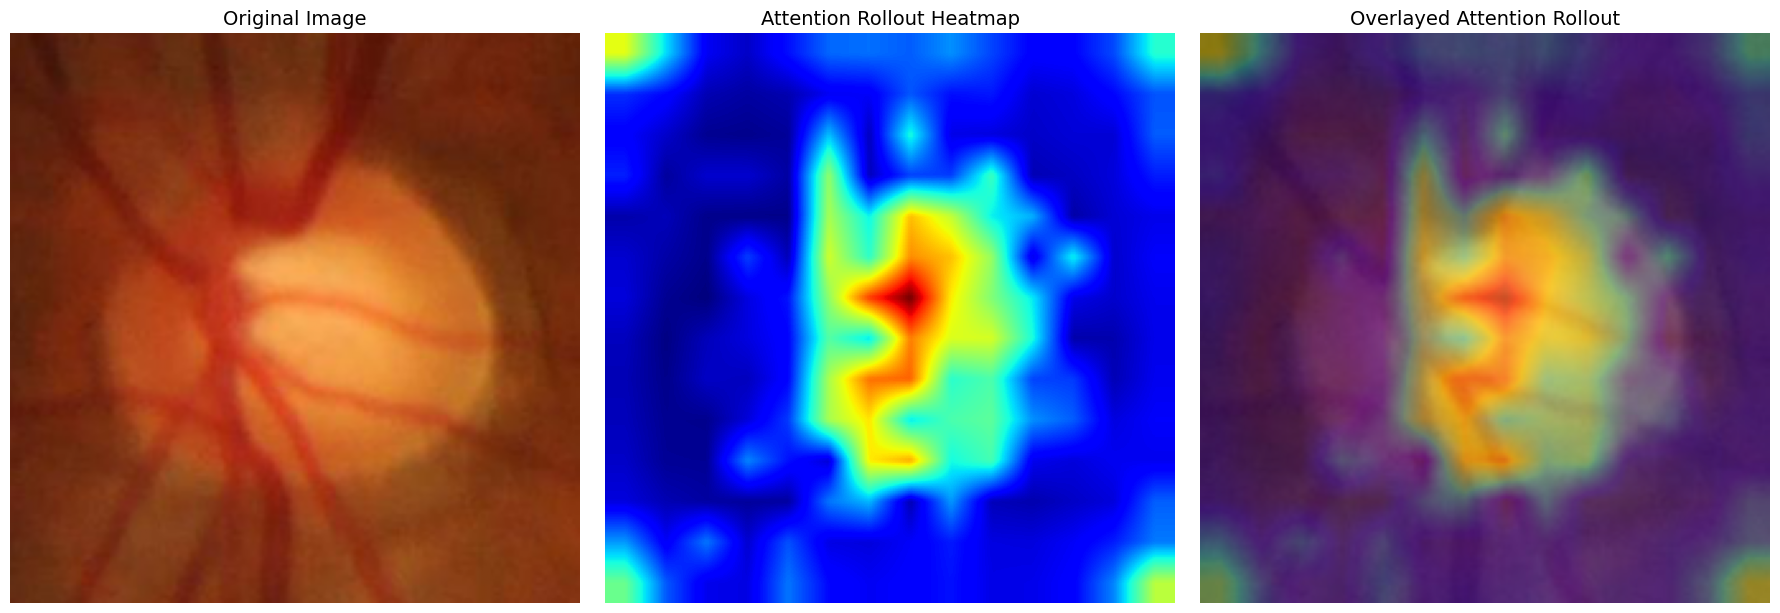

In [92]:
# Plot 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_np)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis("off")

axes[1].imshow(attention_map_resized, cmap="jet")
axes[1].set_title("Attention Rollout Heatmap", fontsize=14)
axes[1].axis("off")

axes[2].imshow(visualization)
axes[2].set_title("Overlayed Attention Rollout", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.show()